In [7]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

# Import Sionna
try:
    import sionna as sn
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

import numpy as np

# For plotting
%matplotlib inline
import matplotlib.pyplot as plt

# PyTorch imports for the implementation of the neural receiver
import torch
import torch.nn as nn
import torch.nn.functional as F


In [50]:
!nvidia-smi

Mon Aug 17 19:51:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5080      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   46C    P5             17W /  360W |    2108MiB /  16303MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [65]:
# --- Parameters ---
EBN0_DB_MIN = 0.0
EBN0_DB_MAX = 12.0
NUM_BITS_PER_SYMBOL = 6  # 64-QAM (Requires bit vectors divisible by 6)

# LDPC Parameters: Rate = k/n
K_BITS = NUM_BITS_PER_SYMBOL * 50 # Multiple of 6
N_BITS = NUM_BITS_PER_SYMBOL * 100 # Multiple of 6

###############################
# 1. Uncoded Model
###############################
class UncodedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.constellation = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL)
        self.mapper = sn.phy.mapping.Mapper(constellation=self.constellation)
        self.demapper = sn.phy.mapping.Demapper("app", constellation=self.constellation)
        self.binary_source = sn.phy.mapping.BinarySource()
        self.awgn_channel = sn.phy.channel.AWGN()

    def forward(self, batch_size, ebno_db):
        no = sn.phy.utils.ebnodb2no(ebno_db,
                                    num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                                    coderate=1.0)
        
        # Block length set to K_BITS so payload size matches the LDPC model
        bits = self.binary_source([batch_size, K_BITS])
        x = self.mapper(bits)
        y = self.awgn_channel(x, no)
        llr = self.demapper(y, no)
        return bits, llr


###############################
# 2. LDPC Coded Model
###############################
class LDPCModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.constellation = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL)
        self.mapper = sn.phy.mapping.Mapper(constellation=self.constellation)
        self.demapper = sn.phy.mapping.Demapper("app", constellation=self.constellation)
        self.binary_source = sn.phy.mapping.BinarySource()
        self.awgn_channel = sn.phy.channel.AWGN()

        self.k = K_BITS
        self.n = N_BITS
        self.coderate = self.k / self.n

        self.encoder = sn.phy.fec.ldpc.LDPC5GEncoder(self.k, self.n)
        self.decoder = sn.phy.fec.ldpc.LDPC5GDecoder(self.encoder)

    def forward(self, batch_size, ebno_db):
        no = sn.phy.utils.ebnodb2no(ebno_db,
                                    num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                                    coderate=self.coderate)

        bits = self.binary_source([batch_size, self.k])
        codewords = self.encoder(bits)
        x = self.mapper(codewords)
        y = self.awgn_channel(x, no)
        llr = self.demapper(y, no)
        b_hat = self.decoder(llr)
        return bits, b_hat

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.0052e-01 | 1.0000e+00 |       60156 |      300000 |         1000 |        1000 |         0.0 |reached target block errors
      1.0 | 1.7770e-01 | 1.0000e+00 |       53309 |      300000 |         1000 |        1000 |         0.0 |reached target block errors
      2.0 | 1.5811e-01 | 1.0000e+00 |       47432 |      300000 |         1000 |        1000 |         0.0 |reached target block errors
      3.0 | 1.3697e-01 | 1.0000e+00 |       41091 |      300000 |         1000 |        1000 |         0.0 |reached target block errors
      4.0 | 1.1819e-01 | 1.0000e+00 |       35456 |      300000 |         1000 |        1000 |         0.0 |reached target block errors
      5.0 | 1.0010e-01 | 1.0000e+00 |       30030 |      300000 |

(tensor([3.1323e-01, 2.9127e-01, 2.6482e-01, 2.3696e-01, 1.9585e-01, 1.2783e-01,
         3.8263e-02, 2.0633e-03, 5.2867e-05, 6.6667e-08, 0.0000e+00, 0.0000e+00,
         0.0000e+00]),
 tensor([1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 9.4000e-01,
         4.1700e-01, 3.6333e-02, 8.6000e-04, 2.0000e-05, 0.0000e+00, 0.0000e+00,
         0.0000e+00]))

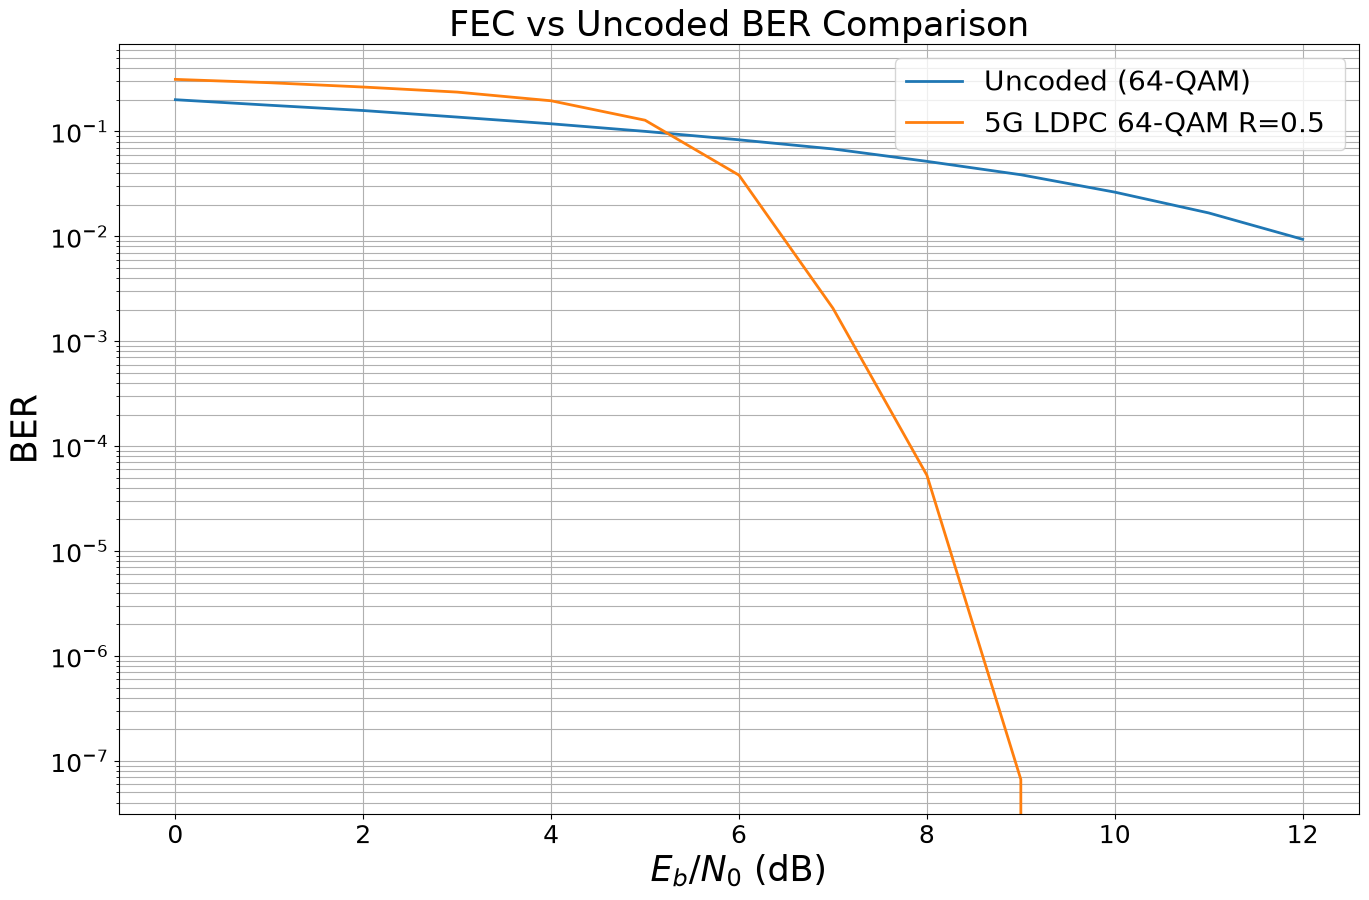

In [66]:
###############################
# 3. Execution & Plotting
###############################
uncoded_model = UncodedModel()
ldpc_model = LDPCModel()

ber_plots = sn.phy.utils.PlotBER("FEC vs Uncoded BER Comparison")
ebno_range = np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 13)

# Uncoded run (soft_estimates=True for raw Demapper LLRs)
ber_plots.simulate(uncoded_model,
                   ebno_dbs=ebno_range,
                   batch_size=1000,
                   num_target_block_errors=100,
                   legend="Uncoded (64-QAM)",
                   soft_estimates=True,
                   max_mc_iter=50,
                   show_fig=False)

# LDPC run (soft_estimates=False for Decoder hard decisions)
ber_plots.simulate(ldpc_model,
                   ebno_dbs=ebno_range,
                   batch_size=1000,
                   num_target_block_errors=100,
                   legend="5G LDPC 64-QAM R="+str(ldpc_model.coderate)+" ",
                   soft_estimates=False,
                   max_mc_iter=50,
                   show_fig=True)